# Finite-section ISTM reconstruction for KdV

This notebook implements the numerical inverse-scattering reconstruction proposed in `152.pdf`, especially equations (6.4)-(6.9), (9.2)-(9.4), and the recovery formulas (2.19)-(2.20). The input is scattering data

- right data `J+ = {s+(rho), tau_k, alpha+_k}` with `side = :right`, or
- left data `J- = {s-(rho), tau_k, alpha-_k}` with `side = :left`.

For a prescribed time `t`, the KdV evolution is applied directly to scattering data:

```julia
s±(rho,t) = s±(rho) * exp(±8im*rho^3*t)
alpha±_k(t) = alpha±_k * exp(±8*tau_k^3*t)
```

The finite-section systems recover the first Fourier-Laguerre coefficients `a0(x)` or `b0(x)`, then reconstruct

```julia
q = (a0'' - a0') / (1 + a0)      # right data
q = (b0'' + b0') / (1 + b0)      # left data
```

In [1]:
using LinearAlgebra
using Statistics

signpow(k::Integer) = isodd(k) ? -1.0 : 1.0
sech(x) = inv(cosh(x));

In [2]:
"""
    ZeroReflection()

Callable zero reflection coefficient. Using this type lets the finite-section
assembly skip quadrature terms in reflectionless examples.
"""
struct ZeroReflection end
(::ZeroReflection)(rho) = zero(ComplexF64)

const zero_reflection = ZeroReflection()

"""
    ScatteringData(side, tau, alpha, reflection)

Scattering data for the KdV inverse scattering step.

- `side = :right` represents `J+` and uses equations (6.4)-(6.5).
- `side = :left` represents `J-` and uses equations (6.6)-(6.7).
- `tau[k] > 0` corresponds to eigenvalue `lambda_k = -tau[k]^2`.
- `alpha[k]` is the norming constant for the chosen side.
- `reflection(rho)` evaluates `s+(rho)` or `s-(rho)` on the real axis.
"""
struct ScatteringData{F}
    side::Symbol
    tau::Vector{Float64}
    alpha::Vector{Float64}
    reflection::F
end

function ScatteringData(side::Symbol, tau, alpha, reflection=zero_reflection)
    @assert side in (:right, :left) "side must be :right or :left"
    @assert length(tau) == length(alpha) "tau and alpha must have the same length"
    @assert all(>(0), tau) "all tau values must be positive"
    return ScatteringData(side, Float64.(collect(tau)), Float64.(collect(alpha)), reflection)
end

"""
    evolve(data, t)

Apply the KdV scattering-data evolution law from Section 4 of the paper.
"""
function evolve(data::ScatteringData, t::Real)
    sgn = data.side == :right ? 1.0 : -1.0
    evolved_alpha = data.alpha .* exp.(sgn .* 8 .* data.tau.^3 .* t)
    evolved_reflection = data.reflection isa ZeroReflection ? zero_reflection :
        (rho -> data.reflection(rho) * exp(sgn * 8im * rho^3 * t))
    return ScatteringData(data.side, data.tau, evolved_alpha, evolved_reflection)
end;

In [3]:
"""
    reflection_integral(reflection, xeff, mpow, npow; Ni=4096)

Compute the oscillatory integral from equation (9.4):

    integral s(rho) exp(2im*rho*xeff)
             (1/2 + im*rho)^mpow / (1/2 - im*rho)^npow d rho.

The change of variables z = exp(im*theta) maps the real rho-axis to the unit
circle. A midpoint trapezoidal rule avoids the endpoint z = -1, which represents
|rho| = infinity.
"""
function reflection_integral(reflection, xeff, mpow::Int, npow::Int; Ni::Int=4096)
    reflection isa ZeroReflection && return zero(ComplexF64)

    s = 0.0 + 0.0im
    dtheta = 2π / Ni
    for j in 0:Ni-1
        theta = -π + (j + 0.5) * dtheta
        z = cis(theta)
        rho = real(im * (1 - z) / (2 * (1 + z)))
        s += reflection(rho) * exp((z - 1) / (z + 1) * xeff) *
             z^(mpow + 1) * (z + 1)^(npow - mpow - 2)
    end
    return dtheta * s
end

"""
    finite_section_coefficients(data, x; Ns=5, Ni=4096)

Solve the finite-section system at one spatial point. Returns the vector
`[a0, a1, ..., a_Ns]` for right data or `[b0, b1, ..., b_Ns]` for left data.
"""
function finite_section_coefficients(data::ScatteringData, x; Ns::Int=5, Ni::Int=4096)
    N = Ns + 1
    M = Matrix{ComplexF64}(I, N, N)
    rhs = zeros(ComplexF64, N)

    xdisc = data.side == :right ? -2x : 2x
    xeff = data.side == :right ? x : -x

    refl_mat = [reflection_integral(data.reflection, xeff, p, p + 2; Ni=Ni) / (2π) for p in 0:2Ns]
    refl_rhs = [reflection_integral(data.reflection, xeff, m, m + 1; Ni=Ni) / (2π) for m in 0:Ns]

    for m in 0:Ns
        disc_rhs = zero(ComplexF64)
        for (tau, alpha) in zip(data.tau, data.alpha)
            disc_rhs += alpha * exp(tau * xdisc) * (0.5 - tau)^m / (0.5 + tau)^(m + 1)
        end
        rhs[m + 1] = signpow(m + 1) * (disc_rhs + refl_rhs[m + 1])

        for n in 0:Ns
            p = m + n
            disc_entry = zero(ComplexF64)
            for (tau, alpha) in zip(data.tau, data.alpha)
                disc_entry += alpha * exp(tau * xdisc) * (0.5 - tau)^p / (0.5 + tau)^(p + 2)
            end
            M[m + 1, n + 1] += signpow(p) * (disc_entry + refl_mat[p + 1])
        end
    end

    return M \ rhs
end;

In [4]:
"""
    finite_difference_1_2(x, y)

Return first and second derivatives on a uniform grid. Interior points use a
five-point centered stencil; boundary points use lower-order one-sided stencils.
"""
function finite_difference_1_2(x::AbstractVector, y::AbstractVector)
    n = length(x)
    @assert n >= 5 "need at least five grid points"
    h = x[2] - x[1]
    @assert maximum(abs.((x[2:end] .- x[1:end-1]) .- h)) < 100eps(Float64) * max(1, abs(h))

    dy = similar(y, ComplexF64)
    d2y = similar(y, ComplexF64)

    dy[1] = (-3y[1] + 4y[2] - y[3]) / (2h)
    dy[end] = (3y[end] - 4y[end-1] + y[end-2]) / (2h)
    d2y[1] = (2y[1] - 5y[2] + 4y[3] - y[4]) / h^2
    d2y[end] = (2y[end] - 5y[end-1] + 4y[end-2] - y[end-3]) / h^2

    for i in 2:n-1
        dy[i] = (y[i+1] - y[i-1]) / (2h)
        d2y[i] = (y[i+1] - 2y[i] + y[i-1]) / h^2
    end

    for i in 3:n-2
        dy[i] = (-y[i+2] + 8y[i+1] - 8y[i-1] + y[i-2]) / (12h)
        d2y[i] = (-y[i+2] + 16y[i+1] - 30y[i] + 16y[i-1] - y[i-2]) / (12h^2)
    end

    return dy, d2y
end

"""
    recover_potential(data, xgrid; Ns=5, Ni=4096)

Recover `q(x)` from one side of the scattering data. Returns `(q, c0)`, where
`c0` is `a0` for right data and `b0` for left data.
"""
function recover_potential(data::ScatteringData, xgrid; Ns::Int=5, Ni::Int=4096)
    c0 = [finite_section_coefficients(data, x; Ns=Ns, Ni=Ni)[1] for x in xgrid]
    dc0, d2c0 = finite_difference_1_2(xgrid, c0)

    q = data.side == :right ? (d2c0 .- dc0) ./ (1 .+ c0) :
                              (d2c0 .+ dc0) ./ (1 .+ c0)
    return real.(q), c0
end

"""
    recover_potential(right_data, left_data, xgrid; Ns=5, Ni=4096, switch=0.0)

Recover using both right and left scattering data. The method computes both
branches over the full grid, then uses the left branch for `x < switch` and the
right branch for `x >= switch`. This keeps derivatives branch-consistent.
"""
function recover_potential(right_data::ScatteringData, left_data::ScatteringData, xgrid;
                           Ns::Int=5, Ni::Int=4096, switch=0.0)
    @assert right_data.side == :right
    @assert left_data.side == :left

    qright, a0 = recover_potential(right_data, xgrid; Ns=Ns, Ni=Ni)
    qleft, b0 = recover_potential(left_data, xgrid; Ns=Ns, Ni=Ni)

    q = similar(qright)
    for i in eachindex(xgrid)
        q[i] = xgrid[i] < switch ? qleft[i] : qright[i]
    end

    return q, qright, qleft, a0, b0
end

"""
    kdv_from_scattering(right0, left0, xgrid, t; Ns=5, Ni=4096, switch=0.0)

Evolve the initial scattering data to time `t` and reconstruct `u(x,t)`.
"""
function kdv_from_scattering(right0::ScatteringData, left0::ScatteringData, xgrid, t;
                             Ns::Int=5, Ni::Int=4096, switch=0.0)
    return recover_potential(evolve(right0, t), evolve(left0, t), xgrid;
                             Ns=Ns, Ni=Ni, switch=switch)
end;

## Validation: reflectionless one-soliton data

For Example 9.2 in the paper,

```julia
q(x) = -c/2 * sech(sqrt(c)*x/2)^2
```

has one eigenvalue `lambda = -c/4`, so `tau = sqrt(c)/2`, zero reflection, and `alpha+ = alpha- = sqrt(c)`. The exact KdV solution is the traveling soliton

```julia
u(x,t) = -c/2 * sech(sqrt(c)*(x - c*t)/2)^2
```

In [5]:
c = π
right0 = ScatteringData(:right, [sqrt(c) / 2], [sqrt(c)], zero_reflection)
left0 = ScatteringData(:left, [sqrt(c) / 2], [sqrt(c)], zero_reflection)

xgrid = collect(range(-7, 7, length=1001))
t = 0.0

u, uright, uleft, a0, b0 = kdv_from_scattering(right0, left0, xgrid, t; Ns=8, Ni=64)
uexact = [-c / 2 * sech(sqrt(c) * (x - c*t) / 2)^2 for x in xgrid]

# Ignore a few endpoints where finite-difference boundary stencils dominate.
interior = 5:length(xgrid)-4
max_error = maximum(abs.(u[interior] .- uexact[interior]))
mean_error = mean(abs.(u[interior] .- uexact[interior]))

(max_error=max_error, mean_error=mean_error)

(max_error = 2.330303550124313e-8, mean_error = 2.020567770255647e-9)

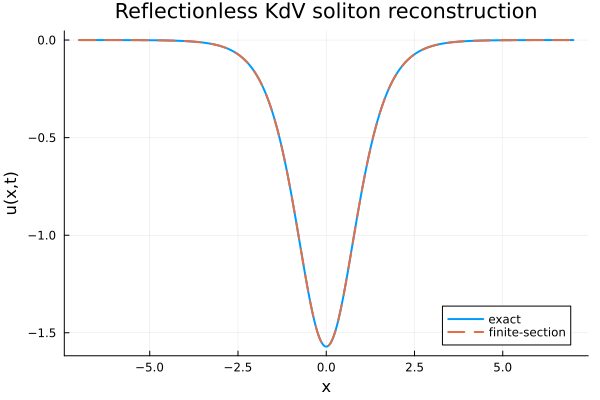

In [6]:
# Optional plot. If Plots.jl is not installed, the numerical result above is still available.
try
    using Plots
    plot(xgrid, uexact, label="exact", linewidth=2)
    plot!(xgrid, u, label="finite-section", linestyle=:dash, linewidth=2)
    xlabel!("x")
    ylabel!("u(x,t)")
    title!("Reflectionless KdV soliton reconstruction")
catch err
    @info "Install Plots.jl for visualization" exception=(err, catch_backtrace())
end

## Using your own scattering data

Replace `tau`, `alpha`, and the reflection coefficient functions below. Increase `Ns` for the finite-section size and `Ni` for the unit-circle quadrature resolution when the reflection coefficient is nonzero or highly oscillatory.

In [7]:
# Template for custom data.
# tau_values = [tau1, tau2, ...]
# alpha_right = [alpha1_plus, alpha2_plus, ...]
# alpha_left = [alpha1_minus, alpha2_minus, ...]
# splus = rho -> ... + 0im
# sminus = rho -> ... + 0im
#
# right_data = ScatteringData(:right, tau_values, alpha_right, splus)
# left_data = ScatteringData(:left, tau_values, alpha_left, sminus)
# x = collect(range(-10, 10, length=1201))
# u_t, _, _, _, _ = kdv_from_scattering(right_data, left_data, x, 0.1; Ns=8, Ni=8192)